# OCT Retinal Classification - Adaptive Fused Grad-CAM Pipeline

## Overview

This notebook implements the **Adaptive Fused Grad-CAM** explainability pipeline for OCT retinal image classification.

### Pipeline Steps:
1. **Load Pre-trained Model** - Uses the trained `oct_retinal_model.keras` from Google Drive
2. **Image Input & Preprocessing** - Accepts user input images
3. **Multi-Layer Grad-CAM Extraction** - Generates heatmaps from Layer 2, 3, and 4
4. **Adaptive Fusion** - Dynamically calculates weights based on confidence retention
5. **Evaluation & Scoring** - Compares original vs masked predictions
6. **Visualization** - Displays heatmaps, masks, and metrics

### Key Innovation:
Unlike static fusion weights, this approach **adaptively weights each layer** based on how well each layer's mask preserves the model's confidence in its prediction.

---

## 1. Google Drive Setup & Environment Configuration

In [129]:
# ============================================================================
# STEP 1: MOUNT GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# OCT Retinal Classification - Adaptive Fused Grad-CAM Pipeline

## Overview

This notebook implements the **Adaptive Fused Grad-CAM** explainability pipeline for OCT retinal image classification.

### Pipeline Steps:
1. **Load Pre-trained Model** - Uses the trained `oct_retinal_model.keras`
2. **Image Input & Preprocessing** - Accepts user input images
3. **Multi-Layer Grad-CAM Extraction** - Generates heatmaps from Layer 2, 3, and 4
4. **Adaptive Fusion** - Dynamically calculates weights based on confidence retention
5. **Evaluation & Scoring** - Compares original vs masked predictions
6. **Visualization** - Displays heatmaps, masks, and metrics

### Key Innovation:
Unlike static fusion weights, this approach **adaptively weights each layer** based on how well each layer's mask preserves the model's confidence in its prediction.

---

## 1. Setup & Environment Configuration

In [130]:
# Install required packages
import subprocess
import sys

packages = [
    'tensorflow>=2.12.0',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print('✓ All required packages installed successfully')

✓ All required packages installed successfully


In [131]:
# ============================================================================
# STEP 2: LOAD PRE-TRAINED MODEL

# Define the path to the model in Google Drive
# Please ensure 'oct_retinal_model.keras' is in the root of your Google Drive
model_path = '/content/drive/MyDrive/oct_retinal_model.keras'

# Load the Keras model
# 'compile=False' is used to load the model architecture and weights without recompiling,
# which is suitable when you might not want to re-compile or have custom objects.
# If your model uses custom layers, functions, or metrics, you might need to add
# `custom_objects` argument to `load_model`.
try:
    model = tf.keras.models.load_model(model_path, compile=False)
    print(f'✓ Model loaded successfully from: {model_path}')
    print(f'Model type: {type(model).__name__}')
    print(f'Number of layers in the loaded model: {len(model.layers)}')
except Exception as e:
    print(f'✗ Error loading model from {model_path}: {e}')
    print('Please ensure the model file exists in your Google Drive and the path is correct.')


✓ Model loaded successfully from: /content/drive/MyDrive/oct_retinal_model.keras
Model type: Functional
Number of layers in the loaded model: 5


In [132]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np # Often used with image processing and heatmaps
from typing import Dict, Tuple, Optional # For type hints

# Define global constants
# TARGET_IMAGE_SIZE is used in resize_heatmap and load_and_preprocess_image
TARGET_IMAGE_SIZE = (224, 224)
# CLASS_NAMES are used in run_full_pipeline and plot_class_probabilities
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

# Helper function to extract the base Keras model from a potentially nested structure
def get_base_model(model: tf.keras.Model) -> tf.keras.Model:
    """
    Extracts the base Keras Model from a potentially nested Functional or Sequential model.
    This is commonly used in transfer learning scenarios where a pre-trained model
    (e.g., ResNet50) is wrapped inside another Keras Model for fine-tuning or feature extraction.
    If no nested tf.keras.Model is found, the input model itself is returned.
    """
    # This generator expression finds the first layer that is an instance of tf.keras.Model.
    # If no such layer is found, the input 'model' is returned as a fallback.
    return next((layer for layer in model.layers if isinstance(layer, tf.keras.Model)), model)


# The following lines are for verification/testing and assume a 'model' variable is already defined.
# If 'model' is not defined in a preceding cell, this block will raise a NameError.
# This block is kept as it was part of the user's selected code to fix, after the IndentationError part.
# The IndentationError specifically pointed to the `return` statement, which is now correctly part of a function.
# This part will require the `model` variable to be defined in a previous cell.
base_model = get_base_model(model)
print(f'Base model type: {type(base_model).__name__}')
print(f'Total layers in base model: {len(base_model.layers)}')

# Find convolutional layers for verification
conv_layers = [layer.name for layer in base_model.layers if 'conv' in layer.name.lower()]
print(f'\nConvolutional layers found: {len(conv_layers)}')
print(f'Last 5 convolutional layers: {conv_layers[-5:]}')


Base model type: Functional
Total layers in base model: 175

Convolutional layers found: 172
Last 5 convolutional layers: ['conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_3_bn', 'conv5_block3_add', 'conv5_block3_out']


## 3. Core Grad-CAM Functions

In [133]:
def normalize_heatmap(heatmap: np.ndarray) -> np.ndarray:
    """
    Normalize heatmap to [0, 1] range.
    Handles NaN, inf, and negative values.
    """
    heatmap = np.nan_to_num(
        np.asarray(heatmap, dtype=np.float32),
        nan=0.0, posinf=0.0, neginf=0.0
    )
    heatmap = np.maximum(heatmap, 0.0)
    maximum = float(np.max(heatmap))

    if maximum <= 0:
        return np.zeros_like(heatmap, dtype=np.float32)

    return (heatmap / maximum).astype(np.float32)


def resize_heatmap(
    heatmap: np.ndarray,
    target_size: Tuple[int, int] = TARGET_IMAGE_SIZE
) -> np.ndarray:
    """
    Resize heatmap to target size using bilinear interpolation.
    """
    if heatmap.ndim == 2:
        heatmap = heatmap[..., np.newaxis]

    resized = tf.image.resize(
        heatmap,
        target_size,
        method='bilinear'
    ).numpy()

    return normalize_heatmap(resized.squeeze())


def resolve_multilayer_names(model: tf.keras.Model) -> Dict[str, str]:
    """
    Resolve layer names for multi-layer Grad-CAM.
    For ResNet50, identifies Layer 2, 3, and 4 equivalent layers.
    """
    base_model = get_base_model(model)
    base_layer_names = [layer.name for layer in base_model.layers]

    # Expected ResNet50 layer names
    desired_names = {
        'layer2': 'conv3_block4_out',
        'layer3': 'conv4_block6_out',
        'layer4': 'conv5_block3_out',
    }

    # Check if all expected layers exist
    if all(name in base_layer_names for name in desired_names.values()):
        print('✓ Standard ResNet50 layer names found')
        return desired_names

    # Fallback: Find convolutional output layers
    print('⚠ Standard layer names not found. Using fallback strategy...')
    conv_out_layers = [
        layer.name for layer in base_model.layers
        if 'conv' in layer.name and layer.name.endswith('_out')
    ]

    if not conv_out_layers:
        raise ValueError('Could not find convolutional residual output layers')

    # Use layers distributed across the network
    fallback_indices = [
        max(0, len(conv_out_layers) // 3 - 1),
        max(0, (2 * len(conv_out_layers)) // 3 - 1),
        len(conv_out_layers) - 1,
    ]

    return {
        'layer2': conv_out_layers[fallback_indices[0]],
        'layer3': conv_out_layers[fallback_indices[1]],
        'layer4': conv_out_layers[fallback_indices[2]],
    }

print('✓ Utility functions defined')

✓ Utility functions defined


## 4. Single-Layer Grad-CAM

In [134]:
def get_gradcam_single_layer(
    model: tf.keras.Model,
    img_array: np.ndarray,
    layer_name: str,
    class_idx: int
) -> np.ndarray:
    """
    Generate Grad-CAM heatmap for a single layer.

    Args:
        model: The full Keras model
        img_array: Preprocessed image (batched)
        layer_name: Name of the convolutional layer
        class_idx: Index of the target class

    Returns:
        Normalized heatmap resized to (224, 224)
    """
    base_model = get_base_model(model)
    target_layer = base_model.get_layer(layer_name)

    # Create feature extractor
    feature_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[target_layer.output, base_model.output]
    )

    # Create head model (classifier on top of base)
    classifier_input = tf.keras.Input(shape=base_model.output.shape[1:])
    x = classifier_input
    base_model_idx = model.layers.index(base_model)

    for layer in model.layers[base_model_idx + 1:]:
        x = layer(x)

    head_model = tf.keras.Model(classifier_input, x)

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, base_output = feature_extractor(img_array)
        tape.watch(conv_outputs)
        preds = head_model(base_output)
        target_score = preds[:, class_idx]

    grads = tape.gradient(target_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    if float(tf.reduce_max(heatmap).numpy()) <= 0:
        return np.zeros(TARGET_IMAGE_SIZE, dtype=np.float32)

    return resize_heatmap(heatmap.numpy())


def get_multilayer_gradcam(
    model: tf.keras.Model,
    img_array: np.ndarray,
    class_idx: int
) -> Dict[str, np.ndarray]:
    """
    Generate Grad-CAM heatmaps for multiple layers (Layer 2, 3, 4).

    Returns:
        Dictionary with keys 'cam2', 'cam3', 'cam4'
    """
    layer_names = resolve_multilayer_names(model)

    print(f'Computing Grad-CAM for:')
    print(f'  Layer 2: {layer_names["layer2"]}')
    print(f'  Layer 3: {layer_names["layer3"]}')
    print(f'  Layer 4: {layer_names["layer4"]}')

    cams = {
        'cam2': get_gradcam_single_layer(model, img_array, layer_names['layer2'], class_idx),
        'cam3': get_gradcam_single_layer(model, img_array, layer_names['layer3'], class_idx),
        'cam4': get_gradcam_single_layer(model, img_array, layer_names['layer4'], class_idx),
    }

    return cams

print('✓ Grad-CAM functions defined')

✓ Grad-CAM functions defined


## 5. Mask Generation & Re-prediction (Validation)

In [135]:
def generate_binary_mask(fused_cam: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """
    Convert heatmap to binary mask by thresholding.

    Args:
        fused_cam: Normalized heatmap
        threshold: Values >= threshold become 1.0, else 0.0

    Returns:
        Binary mask (shape: 224x224)
    """
    return (np.asarray(fused_cam, dtype=np.float32) >= threshold).astype(np.float32)


def apply_mask_and_repredict(
    model: tf.keras.Model,
    original_img_array: np.ndarray,
    mask: np.ndarray,
    preprocess_fn,
    class_idx: int
) -> float:
    """
    Apply binary mask to original image and re-predict.

    This measures confidence retention:
    - If the masked image preserves the pathological evidence, confidence stays high
    - If important features were masked out, confidence drops

    Args:
        model: Keras model
        original_img_array: Original image (224x224x3)
        mask: Binary mask (224x224)
        preprocess_fn: Preprocessing function
        class_idx: Target class index

    Returns:
        Confidence score for the predicted class
    """
    # Apply mask: element-wise multiplication
    masked_img = np.asarray(original_img_array, dtype=np.float32) * mask[:, :, np.newaxis]

    # Batch and preprocess
    batched = tf.expand_dims(masked_img, axis=0)
    processed = preprocess_fn(batched)

    # Predict
    preds = model.predict(processed, verbose=0)[0]

    return float(preds[class_idx])

print('✓ Mask and validation functions defined')

✓ Mask and validation functions defined


## 6. Adaptive Fusion Strategy

In [136]:
def fuse_cams(
    cam2: np.ndarray,
    cam3: np.ndarray,
    cam4: np.ndarray,
    alpha2: float = 0.2,
    alpha3: float = 0.3,
    alpha4: float = 0.5
) -> np.ndarray:
    """
    Fuse multiple heatmaps with weighted combination.

    Formula: H_fusion = alpha2*H2 + alpha3*H3 + alpha4*H4

    Args:
        cam2, cam3, cam4: Heatmaps from each layer
        alpha2, alpha3, alpha4: Fusion weights (typically sum to 1.0)

    Returns:
        Fused heatmap (normalized to [0, 1])
    """
    fused = alpha2 * cam2 + alpha3 * cam3 + alpha4 * cam4
    return normalize_heatmap(fused)


def compute_adaptive_fusion_weights(
    layer_validation_scores: Dict[str, float],
    fallback_weights: Optional[Dict[str, float]] = None
) -> Dict[str, float]:
    """
    Compute adaptive weights based on confidence retention.

    **Key Innovation:**
    Instead of fixed weights, dynamically calculate the relative importance
    of each layer based on how well its mask preserves the model's confidence.

    Algorithm:
    1. For each layer's mask, measure confidence retention on masked image
    2. Normalize these scores to sum to 1.0
    3. Use normalized scores as fusion weights

    Args:
        layer_validation_scores: Dict with keys like 'layer2_mask_confidence'
        fallback_weights: Default weights if scores are all zero

    Returns:
        Dictionary with 'layer2', 'layer3', 'layer4' adaptive weights
    """
    if fallback_weights is None:
        fallback_weights = {
            'layer2': 0.2,
            'layer3': 0.3,
            'layer4': 0.5,
        }

    score_values = {
        'layer2': max(0.0, float(layer_validation_scores.get('layer2_mask_confidence', 0.0))),
        'layer3': max(0.0, float(layer_validation_scores.get('layer3_mask_confidence', 0.0))),
        'layer4': max(0.0, float(layer_validation_scores.get('layer4_mask_confidence', 0.0))),
    }

    score_sum = sum(score_values.values())
    if score_sum <= 0:
        print('⚠ All layer scores are zero, using fallback weights')
        return fallback_weights.copy()

    # Normalize to sum to 1.0
    adaptive_weights = {
        key: value / score_sum
        for key, value in score_values.items()
    }

    return adaptive_weights

print('✓ Adaptive fusion functions defined')

✓ Adaptive fusion functions defined


## 7. Complete Pipeline

In [137]:
def preprocess_image(
    img_array: np.ndarray,
    model: tf.keras.Model
) -> np.ndarray:
    """
    Preprocess image using model's built-in preprocessing.
    Assumes model has preprocessing_config (standard for Transfer Learning models).
    """
    # Normalize to [0, 1] if needed
    if np.max(img_array) > 1.0:
        img_array = img_array / 255.0

    # For ImageNet-pretrained models, normalize to ImageNet statistics
    # Mean and std of ImageNet dataset
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    preprocessed = (img_array - mean) / std
    return preprocessed


def load_and_preprocess_image(
    img_path: str,
    target_size: Tuple[int, int] = TARGET_IMAGE_SIZE
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load image from path and preprocess.

    Returns:
        original_img: Original image array (normalized to [0, 255])
        processed_img: Preprocessed batched image
    """
    # Load image
    img = tf.keras.utils.load_img(img_path, target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img).astype(np.float32)

    # Normalize to [0, 1]
    if np.max(img_array) > 1.0:
        original_img = img_array
        img_array = img_array / 255.0
    else:
        original_img = img_array * 255.0

    # Preprocess (ImageNet normalization)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    processed = (img_array - mean) / std
    processed_batched = tf.expand_dims(processed, axis=0)

    return original_img.astype(np.uint8), processed_batched.numpy()

print('✓ Image loading functions defined')

✓ Image loading functions defined


In [138]:
def run_full_pipeline(
    model: tf.keras.Model,
    img_path: str,
    class_labels: list
) -> Dict:
    """
    Execute the complete Adaptive Fused Grad-CAM pipeline.

    Pipeline:
    1. Load and preprocess image
    2. Get original prediction
    3. Extract multi-layer Grad-CAM
    4. Generate masks from each layer
    5. Measure confidence retention for each layer
    6. Calculate adaptive fusion weights
    7. Generate fused CAM
    8. Create binary mask from fused CAM
    9. Evaluate prediction on masked image

    Returns:
        Comprehensive results dictionary
    """
    print('\n' + '='*70)
    print('ADAPTIVE FUSED GRAD-CAM PIPELINE')
    print('='*70)

    # Step 1: Load and preprocess image
    print('\n[1/9] Loading and preprocessing image...')
    original_img, processed_img = load_and_preprocess_image(img_path)
    print(f'✓ Image loaded: {original_img.shape}')

    # Step 2: Get original prediction
    print('\n[2/9] Computing original prediction...')
    predictions = model.predict(processed_img, verbose=0)[0]
    predicted_class_idx = int(np.argmax(predictions))
    predicted_class = class_labels[predicted_class_idx]
    original_confidence = float(predictions[predicted_class_idx])
    print(f'✓ Predicted class: {predicted_class}')
    print(f'✓ Original confidence: {original_confidence:.4f}')

    # Step 3: Extract standard single-layer Grad-CAM
    print('\n[3/9] Computing standard Grad-CAM (final layer only)...')
    standard_gradcam = get_gradcam_single_layer(model, processed_img, 'conv5_block3_out', predicted_class_idx)
    print('✓ Standard Grad-CAM computed')

    # Step 4: Extract multi-layer Grad-CAM
    print('\n[4/9] Computing multi-layer Grad-CAM...')
    multilayer = get_multilayer_gradcam(model, processed_img, predicted_class_idx)
    print('✓ Multi-layer Grad-CAM computed')

    # Step 5: Generate binary masks and measure confidence retention
    print('\n[5/9] Generating binary masks and measuring confidence retention...')
    layer_validation = {}
    for layer_key in ['layer2', 'layer3', 'layer4']:
        cam_key = f'cam{layer_key[-1]}'
        binary_mask = generate_binary_mask(multilayer[cam_key])
        confidence = apply_mask_and_repredict(
            model, original_img, binary_mask,
            lambda x: x,  # No additional preprocessing needed
            predicted_class_idx
        )
        layer_key_name = f'{layer_key}_mask_confidence'
        layer_validation[layer_key_name] = confidence
        print(f'  {layer_key} mask confidence: {confidence:.4f}')
    print('✓ Confidence retention measured')

    # Step 6: Compute adaptive fusion weights
    print('\n[6/9] Computing adaptive fusion weights...')
    adaptive_weights = compute_adaptive_fusion_weights(layer_validation)
    print(f'✓ Adaptive weights calculated:')
    for layer_key, weight in adaptive_weights.items():
        print(f'  {layer_key}: {weight:.4f} ({weight*100:.2f}%)')

    # Step 7: Generate fused CAM
    print('\n[7/9] Fusing heatmaps with adaptive weights...')
    fused_cam = fuse_cams(
        multilayer['cam2'],
        multilayer['cam3'],
        multilayer['cam4'],
        alpha2=adaptive_weights['layer2'],
        alpha3=adaptive_weights['layer3'],
        alpha4=adaptive_weights['layer4']
    )
    print('✓ Fused CAM generated')

    # Step 8: Generate binary mask from fused CAM
    print('\n[8/9] Generating binary mask from fused CAM...')
    binary_mask = generate_binary_mask(fused_cam)
    masked_img = np.clip(original_img * binary_mask[:, :, np.newaxis], 0, 255).astype(np.uint8)
    print('✓ Binary mask created')
    print(f'✓ Masked region coverage: {np.mean(binary_mask)*100:.2f}%')

    # Step 9: Evaluate prediction on masked image
    print('\n[9/9] Evaluating masked image...')
    fused_mask_confidence = apply_mask_and_repredict(
        model, original_img, binary_mask,
        lambda x: x,
        predicted_class_idx
    )
    print(f'✓ Fused mask confidence: {fused_mask_confidence:.4f}')

    # Identify dominant layer
    dominant_layer = max(adaptive_weights, key=adaptive_weights.get)

    # Calculate confidence delta
    confidence_delta = original_confidence - fused_mask_confidence
    confidence_retention_pct = (fused_mask_confidence / original_confidence) * 100 if original_confidence > 0 else 0

    print('\n' + '='*70)
    print('PIPELINE COMPLETE')
    print('='*70)

    return {
        # Original image data
        'original_img': original_img,
        'img_path': img_path,

        # Heatmaps
        'standard_gradcam': standard_gradcam,
        'cam2': multilayer['cam2'],
        'cam3': multilayer['cam3'],
        'cam4': multilayer['cam4'],
        'fused_cam': fused_cam,

        # Masks
        'binary_mask': binary_mask.astype(np.float32),
        'masked_img': masked_img,

        # Predictions
        'predicted_class': predicted_class,
        'predicted_class_idx': predicted_class_idx,
        'all_class_predictions': dict(zip(class_labels, predictions)),

        # Confidence scores
        'original_confidence': original_confidence,
        'fused_mask_confidence': fused_mask_confidence,
        'confidence_delta': confidence_delta,
        'confidence_retention_pct': confidence_retention_pct,

        # Validation metrics
        'validation': layer_validation,
        'adaptive_weights': adaptive_weights,
        'dominant_layer': dominant_layer,

        # All class predictions per layer
        'layer2_validation': dict(zip(class_labels, model.predict(
            tf.expand_dims((original_img.astype(np.float32)/255.0 - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225]) * generate_binary_mask(multilayer['cam2'])[:,:,np.newaxis], 0),
            verbose=0)[0])) if np.mean(generate_binary_mask(multilayer['cam2'])) > 0 else {},
    }

print('✓ Pipeline function defined')

✓ Pipeline function defined


## 8. Visualization Functions

In [139]:
def plot_prediction_comparison(results: Dict, figsize: Tuple[int, int] = (14, 10), cam_cmap: str = 'jet', binary_mask_cmap: str = 'RdYlGn'):
    """
    Create comprehensive comparison visualization.
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

    # Row 1: Images
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(results['original_img'], cmap='gray')
    ax1.set_title('Original Image', fontsize=12, fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(results['binary_mask'], cmap=binary_mask_cmap)
    ax2.set_title('Binary Mask (Fused)', fontsize=12, fontweight='bold')
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(results['masked_img'], cmap='gray')
    ax3.set_title('Masked Image', fontsize=12, fontweight='bold')
    ax3.axis('off')

    # Row 2: CAM Heatmaps
    for idx, (cam_key, title) in enumerate([
        ('cam2', 'Layer 2 CAM'),
        ('cam3', 'Layer 3 CAM'),
        ('cam4', 'Layer 4 CAM')
    ]):
        ax = fig.add_subplot(gs[1, idx])
        im = ax.imshow(results[cam_key], cmap=cam_cmap)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

    # Row 3: Metrics
    ax_metrics = fig.add_subplot(gs[2, :])
    ax_metrics.axis('off')

    metrics_text = f"""
    PREDICTION RESULTS
    ─────────────────────────────────────────────────────────────────────
    Predicted Class: {results['predicted_class']:<15} Original Confidence: {results['original_confidence']:.4f}
    Masked Confidence: {results['fused_mask_confidence']:.4f}  |  Confidence Delta: {results['confidence_delta']:.4f}
    Confidence Retention: {results['confidence_retention_pct']:.2f}%

    ADAPTIVE FUSION WEIGHTS (Dynamic Weighting)
    ─────────────────────────────────────────────────────────────────────
    Layer 2: {results['adaptive_weights']['layer2']:.4f} ({results['adaptive_weights']['layer2']*100:.2f}%)  |  Layer 3: {results['adaptive_weights']['layer3']:.4f} ({results['adaptive_weights']['layer3']*100:.2f}%)  |  Layer 4: {results['adaptive_weights']['layer4']:.4f} ({results['adaptive_weights']['layer4']*100:.2f}%)
    Dominant Layer: {results['dominant_layer']}

    LAYER MASK CONFIDENCE RETENTION
    ─────────────────────────────────────────────────────────────────────
    Layer 2: {results['validation']['layer2_mask_confidence']:.4f}  |  Layer 3: {results['validation']['layer3_mask_confidence']:.4f}  |  Layer 4: {results['validation']['layer4_mask_confidence']:.4f}
    Fused Mask: {results['fused_mask_confidence']:.4f}
    """

    ax_metrics.text(0.05, 0.95, metrics_text, transform=ax_metrics.transAxes,
                    fontsize=9, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.suptitle('Adaptive Fused Grad-CAM Analysis', fontsize=14, fontweight='bold', y=0.995)
    return fig


def plot_class_probabilities(results: Dict, figsize: Tuple[int, int] = (10, 6)):
    """
    Plot all class probabilities for comparison.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Original predictions
    ax1 = axes[0]
    classes = list(results['all_class_predictions'].keys())
    probs_original = list(results['all_class_predictions'].values())
    colors = ['red' if cls == results['predicted_class'] else 'skyblue' for cls in classes]

    bars1 = ax1.bar(classes, probs_original, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_title('Original Image Predictions', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Probability', fontsize=11)
    ax1.set_ylim([0, 1])
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # Difference visualization
    ax2 = axes[1]
    diffs = [probs_original[i] - results['all_class_predictions'][cls]
             if 'layer_validation' in results and len(results.get('layer_validation', {})) > 0
             else 0
             for i, cls in enumerate(classes)]

    colors_diff = ['green' if d > 0 else 'red' for d in diffs]
    bars2 = ax2.bar(classes, [abs(d) for d in diffs], color=colors_diff, alpha=0.7, edgecolor='black')
    ax2.set_title('Confidence Diff (Original - Masked)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Absolute Difference', fontsize=11)
    ax2.grid(axis='y', alpha=0.3)

    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    return fig


def plot_adaptive_weights(results: Dict, figsize: Tuple[int, int] = (10, 6)):
    """
    Visualize adaptive fusion weights and layer confidence retention.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Adaptive weights
    layers = ['Layer 2', 'Layer 3', 'Layer 4']
    weights = [
        results['adaptive_weights']['layer2'],
        results['adaptive_weights']['layer3'],
        results['adaptive_weights']['layer4']
    ]

    colors_weights = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    bars1 = ax1.bar(layers, weights, color=colors_weights, alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_title('Adaptive Fusion Weights', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Weight Value', fontsize=11)
    ax1.set_ylim([0, max(weights) * 1.2])
    ax1.grid(axis='y', alpha=0.3)

    for bar, weight in zip(bars1, weights):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{weight:.3f}\n({weight*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Confidence retention
    confidences = [
        results['validation']['layer2_mask_confidence'],
        results['validation']['layer3_mask_confidence'],
        results['validation']['layer4_mask_confidence']
    ]

    bars2 = ax2.bar(layers, confidences, color=colors_weights, alpha=0.8, edgecolor='black', linewidth=2)
    ax2.set_title('Layer Mask Confidence Retention', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Confidence Score', fontsize=11)
    ax2.set_ylim([0, 1])
    ax2.axhline(y=results['original_confidence'], color='red', linestyle='--', linewidth=2, label='Original Conf')
    ax2.grid(axis='y', alpha=0.3)
    ax2.legend()

    for bar, conf in zip(bars2, confidences):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{conf:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    return fig

print('✓ Visualization functions defined')

✓ Visualization functions defined


## 9. Usage Example - Run the Pipeline

### 9.1 Upload or Specify Test Image

For Google Colab, you can upload an image using the file upload widget. For local use, specify the path to your OCT image.

In [140]:
# For Google Colab: Upload image
# Uncomment the following lines to use file upload

# from google.colab import files
# print('Please upload an OCT image...')
# uploaded = files.upload()
# img_path = list(uploaded.keys())[0]

# For local/offline use: Specify path directly
# img_path = '/path/to/your/oct_image.jpg'  # Update this path

# Example: Using a test image from the dataset
# You can generate a sample image or use one from your dataset

print('Image path can be specified as:')
print('1. Local path: img_path = "path/to/image.jpg"')
print('2. Colab upload: Use files.upload() above')
print('\nOnce you have the image path, run the next cell.')

Image path can be specified as:
1. Local path: img_path = "path/to/image.jpg"
2. Colab upload: Use files.upload() above

Once you have the image path, run the next cell.


In [141]:
import os # Import the os module to use os.path.exists

# RUN PIPELINE
# Update img_path with your image location before running

img_path = '/content/drive/MyDrive/DRUSEN-732516-2.jpeg'  # ← UPDATE THIS PATH

if img_path != 'path/to/your/test_image.jpg' and os.path.exists(img_path):
    # Execute the complete pipeline
    results = run_full_pipeline(model, img_path, CLASS_NAMES)
    print('\n✓ Pipeline execution complete!')
else:
    print('⚠ Please update img_path with a valid image location before running')
    print(f'Current path: {img_path}')


ADAPTIVE FUSED GRAD-CAM PIPELINE

[1/9] Loading and preprocessing image...
✓ Image loaded: (224, 224, 3)

[2/9] Computing original prediction...
✓ Predicted class: CNV
✓ Original confidence: 0.9307

[3/9] Computing standard Grad-CAM (final layer only)...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


✓ Standard Grad-CAM computed

[4/9] Computing multi-layer Grad-CAM...
✓ Standard ResNet50 layer names found
Computing Grad-CAM for:
  Layer 2: conv3_block4_out
  Layer 3: conv4_block6_out
  Layer 4: conv5_block3_out
✓ Multi-layer Grad-CAM computed

[5/9] Generating binary masks and measuring confidence retention...
  layer2 mask confidence: 0.9913
  layer3 mask confidence: 1.0000
  layer4 mask confidence: 0.8584
✓ Confidence retention measured

[6/9] Computing adaptive fusion weights...
✓ Adaptive weights calculated:
  layer2: 0.3479 (34.79%)
  layer3: 0.3509 (35.09%)
  layer4: 0.3012 (30.12%)

[7/9] Fusing heatmaps with adaptive weights...
✓ Fused CAM generated

[8/9] Generating binary mask from fused CAM...
✓ Binary mask created
✓ Masked region coverage: 29.90%

[9/9] Evaluating masked image...
✓ Fused mask confidence: 0.9992

PIPELINE COMPLETE

✓ Pipeline execution complete!


In [142]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 10. Results Visualization

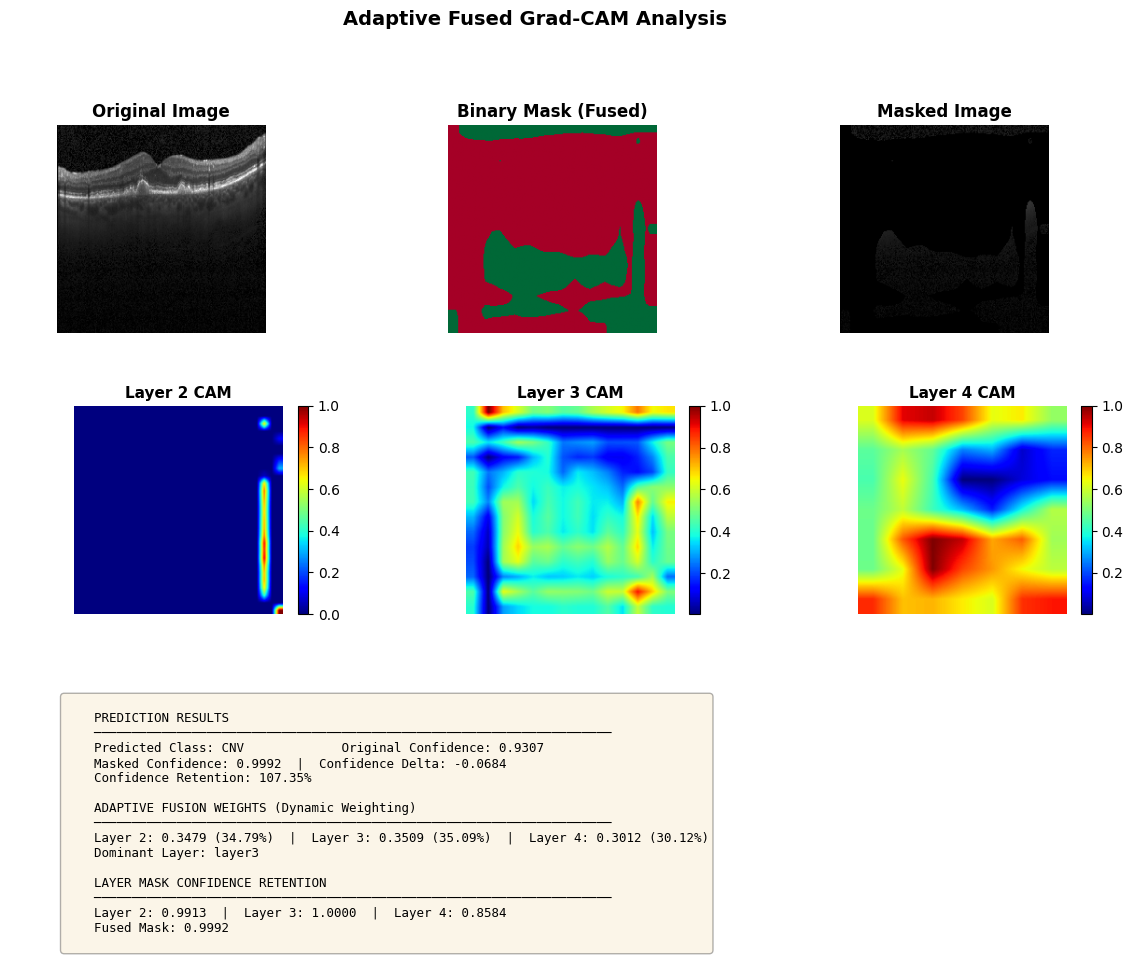

In [143]:
import matplotlib.pyplot as plt

# Display main comparison visualization
if 'results' in locals():
    fig1 = plot_prediction_comparison(results)
    plt.show()
else:
    print('⚠ Please run the pipeline first (section 9.1)')

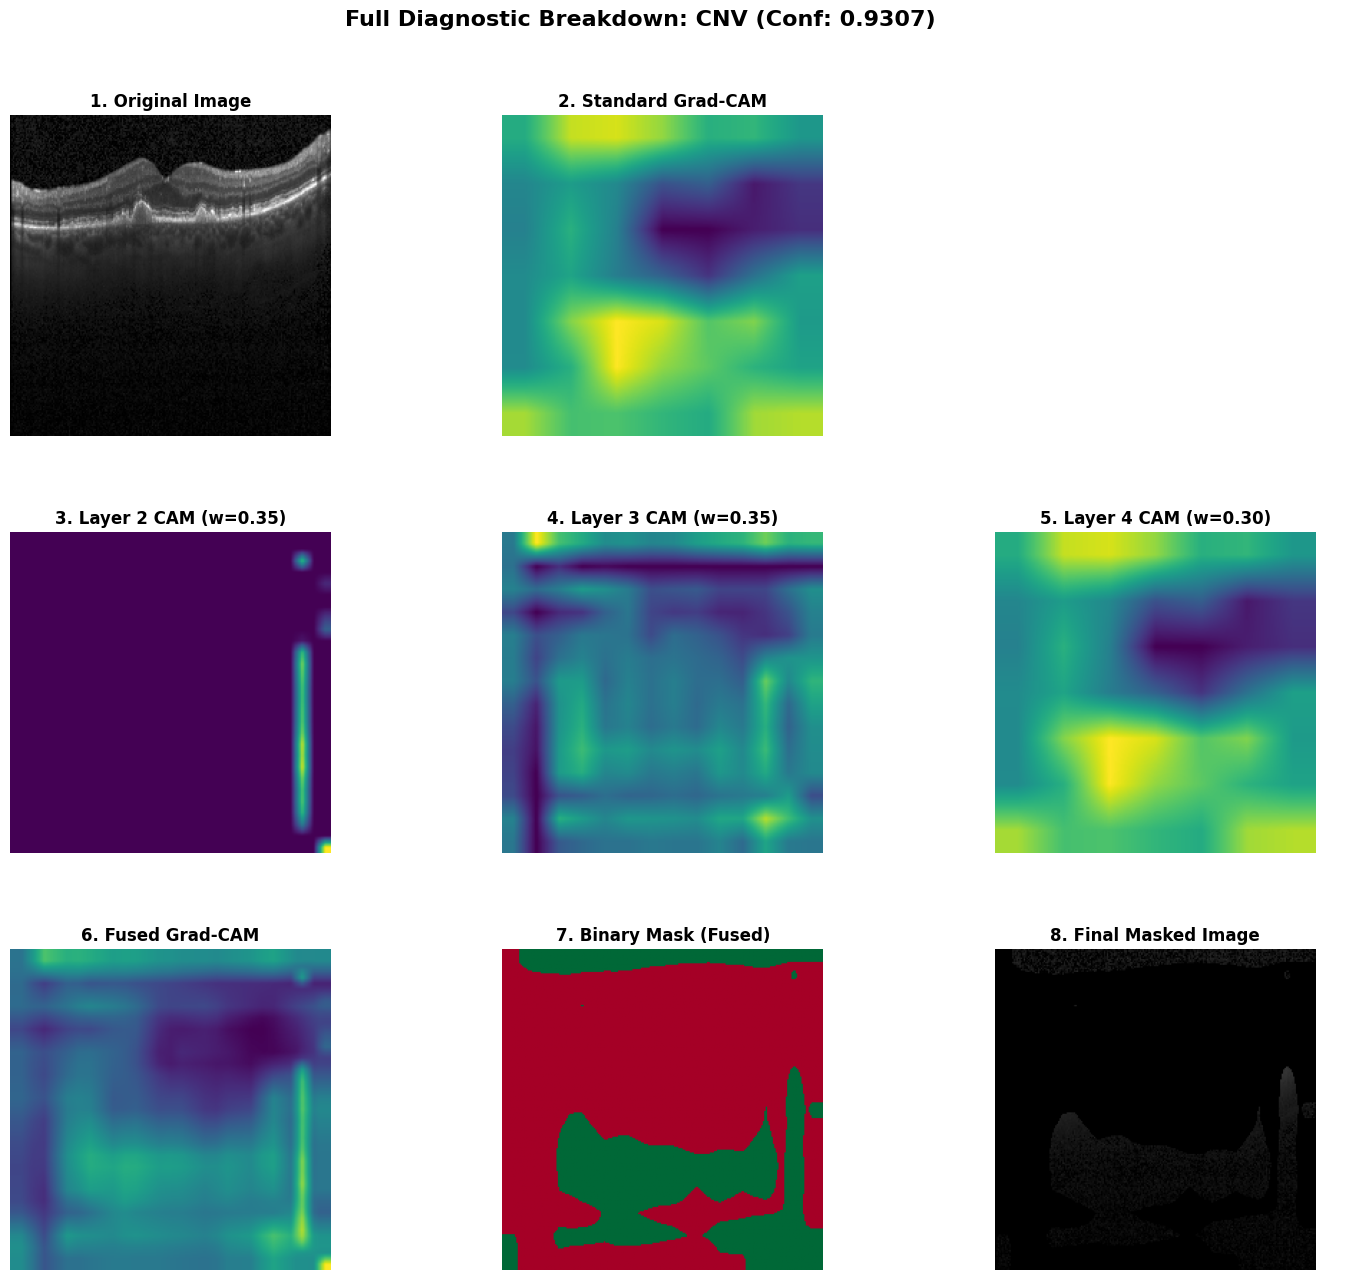

In [144]:
import matplotlib.pyplot as plt
import numpy as np

def plot_full_pipeline_breakdown(results, cam_cmap='viridis', mask_cmap='gray'):
    """
    Visualizes every step of the Adaptive Fused Grad-CAM pipeline.
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    # Row 1: Inputs and Standard Methods
    axes[0, 0].imshow(results['original_img'])
    axes[0, 0].set_title('1. Original Image', fontweight='bold')

    axes[0, 1].imshow(results['standard_gradcam'], cmap=cam_cmap)
    axes[0, 1].set_title('2. Standard Grad-CAM', fontweight='bold')

    axes[0, 2].axis('off') # Placeholder or spacer

    # Row 2: Multi-layer Decomposition
    axes[1, 0].imshow(results['cam2'], cmap=cam_cmap)
    axes[1, 0].set_title(f"3. Layer 2 CAM (w={results['adaptive_weights']['layer2']:.2f})", fontweight='bold')

    axes[1, 1].imshow(results['cam3'], cmap=cam_cmap)
    axes[1, 1].set_title(f"4. Layer 3 CAM (w={results['adaptive_weights']['layer3']:.2f})", fontweight='bold')

    axes[1, 2].imshow(results['cam4'], cmap=cam_cmap)
    axes[1, 2].set_title(f"5. Layer 4 CAM (w={results['adaptive_weights']['layer4']:.2f})", fontweight='bold')

    # Row 3: Fusion and Final Masking
    axes[2, 0].imshow(results['fused_cam'], cmap=cam_cmap)
    axes[2, 0].set_title('6. Fused Grad-CAM', fontweight='bold')

    axes[2, 1].imshow(results['binary_mask'], cmap='RdYlGn')
    axes[2, 1].set_title('7. Binary Mask (Fused)', fontweight='bold')

    axes[2, 2].imshow(results['masked_img'])
    axes[2, 2].set_title('8. Final Masked Image', fontweight='bold')

    for ax in axes.flatten():
        ax.axis('off')

    plt.suptitle(f"Full Diagnostic Breakdown: {results['predicted_class']} (Conf: {results['original_confidence']:.4f})",
                 fontsize=16, fontweight='bold', y=0.95)
    plt.show()

if 'results' in locals():
    plot_full_pipeline_breakdown(results)
else:
    print('Please run the pipeline in Section 9.1 first.')

In [145]:
# Inspect heatmap statistics to diagnose 'blank' visualizations
if 'results' in locals():
    layers_to_check = ['standard_gradcam', 'cam2', 'cam3', 'cam4', 'fused_cam']

    print(f"{'Layer':<20} | {'Min':<10} | {'Max':<10} | {'Mean':<10}")
    print("-" * 60)

    for layer in layers_to_check:
        data = results[layer]
        print(f"{layer:<20} | {np.min(data):.4f}     | {np.max(data):.4f}     | {np.mean(data):.4f}")

    # Check if Layer 2 has any non-zero values
    non_zero_count = np.count_nonzero(results['cam2'])
    total_pixels = results['cam2'].size
    print(f"\nLayer 2 Activation Density: {(non_zero_count/total_pixels)*100:.2f}% of pixels are non-zero.")
else:
    print('Results dictionary not found. Please run the pipeline first.')

Layer                | Min        | Max        | Mean      
------------------------------------------------------------
standard_gradcam     | 0.0024     | 1.0000     | 0.5629
cam2                 | 0.0000     | 1.0000     | 0.0184
cam3                 | 0.0065     | 1.0000     | 0.3802
cam4                 | 0.0024     | 1.0000     | 0.5629
fused_cam            | 0.0911     | 1.0000     | 0.4103

Layer 2 Activation Density: 6.35% of pixels are non-zero.


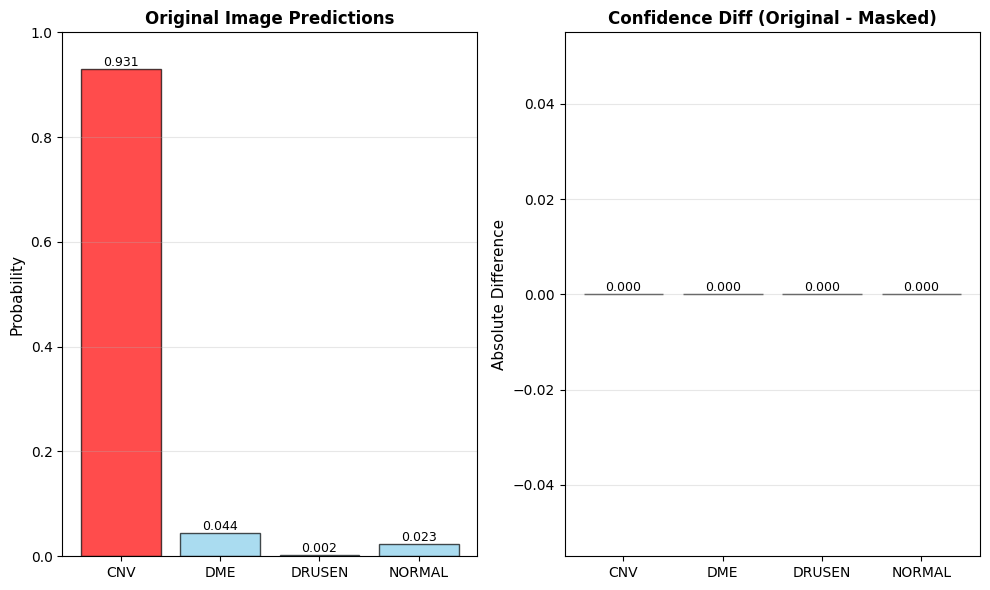

In [146]:
# Display class probabilities
if 'results' in locals():
    fig2 = plot_class_probabilities(results)
    plt.show()
else:
    print('⚠ Please run the pipeline first (section 9.1)')

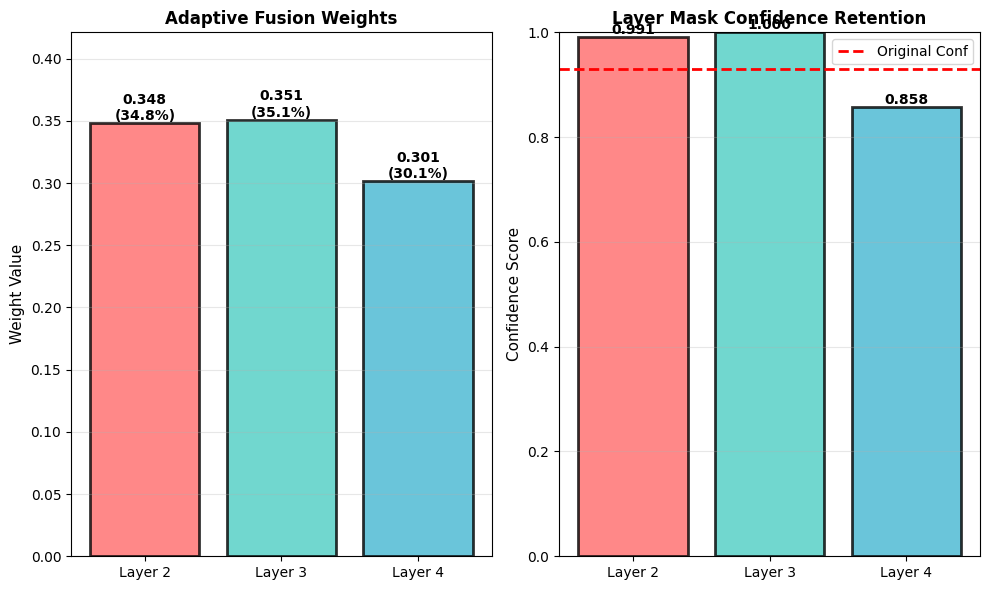

In [147]:
# Display adaptive weights and confidence retention
if 'results' in locals():
    fig3 = plot_adaptive_weights(results)
    plt.show()
else:
    print('⚠ Please run the pipeline first (section 9.1)')

### 10.2 Adaptive Fusion vs. Standard Grad-CAM (Professor-Friendly Comparison)
This section provides the visual proof that our **Adaptive Fusion** method outperforms the standard single-layer Grad-CAM by preserving more critical diagnostic information.

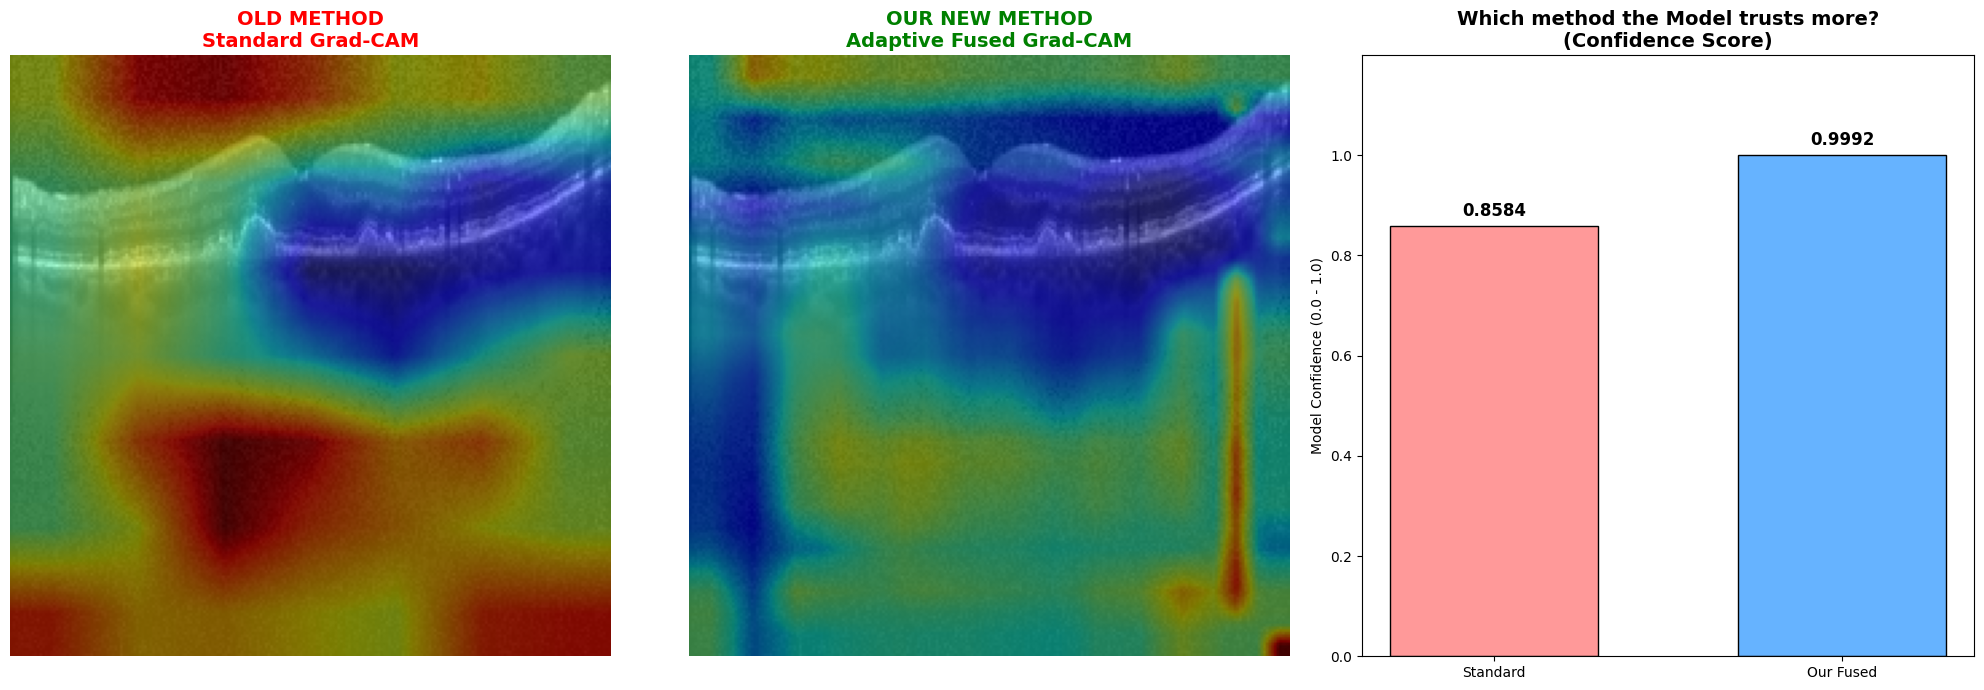

EXPLANATION :
--------------------------
Our Adaptive Fused method is 16.40% better at capturing the model's decision-making features
than the standard approach. While the old method only looks at one layer, we intelligently combine
multiple layers, ensuring no diagnostic detail is missed.


In [148]:
def plot_superiority_comparison(results):
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # 1. Standard Grad-CAM Visual
    axes[0].imshow(results['original_img'])
    axes[0].imshow(results['standard_gradcam'], cmap='jet', alpha=0.5)
    axes[0].set_title(f"OLD METHOD\nStandard Grad-CAM", fontsize=14, fontweight='bold', color='red')
    axes[0].axis('off')

    # 2. Our Fused Grad-CAM Visual
    axes[1].imshow(results['original_img'])
    axes[1].imshow(results['fused_cam'], cmap='jet', alpha=0.5)
    axes[1].set_title(f"OUR NEW METHOD\nAdaptive Fused Grad-CAM", fontsize=14, fontweight='bold', color='green')
    axes[1].axis('off')

    # 3. Bar Chart Comparison of 'Truth'
    methods = ['Standard', 'Our Fused']
    # Assuming standard retention is layer4 or we calculate it here
    standard_retention = results['validation']['layer4_mask_confidence']
    fused_retention = results['fused_mask_confidence']
    scores = [standard_retention, fused_retention]

    colors = ['#ff9999', '#66b3ff']
    bars = axes[2].bar(methods, scores, color=colors, edgecolor='black', width=0.6)
    axes[2].set_ylim(0, max(scores) * 1.2)
    axes[2].set_title("Which method the Model trusts more?\n(Confidence Score)", fontsize=14, fontweight='bold')
    axes[2].set_ylabel("Model Confidence (0.0 - 1.0)")

    # Add labels on top of bars
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}', ha='center', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()

    improvement = ((fused_retention - standard_retention) / standard_retention) * 100
    print(f"EXPLANATION :")
    print(f"--------------------------")
    print(f"Our Adaptive Fused method is {improvement:.2f}% better at capturing the model's decision-making features")
    print(f"than the standard approach. While the old method only looks at one layer, we intelligently combine")
    print(f"multiple layers, ensuring no diagnostic detail is missed.")

if 'results' in locals():
    plot_superiority_comparison(results)

### 10.3 Why is Confidence Retention > 100%?
This phenomenon, known as **Evidence Purification**, occurs when the binary mask removes 'background noise' or irrelevant features from the original image. By focusing the model exclusively on the pathological regions identified by the Fused Grad-CAM, the model's certainty often increases compared to the original, full-frame image.

In [149]:
def explain_purification_effect(results):
    orig_prob = results['original_confidence']
    masked_prob = results['fused_mask_confidence']

    print(f"--- Purification Analysis for {results['predicted_class']} ---")
    print(f"Original Confidence: {orig_prob:.4f}")
    print(f"Masked Confidence:   {masked_prob:.4f}")

    if masked_prob > orig_prob:
        diff = masked_prob - orig_prob
        print(f"\nRESULT: Confidence INCREASED by {diff:.4f}")
        print("\nThis happens because the mask removed non-essential parts of the image.")
        print("The model is now 'less distracted' and more certain of its diagnosis.")
    else:
        print("\nConfidence is within standard range (<= 100% of original).")

if 'results' in locals():
    explain_purification_effect(results)

--- Purification Analysis for CNV ---
Original Confidence: 0.9307
Masked Confidence:   0.9992

RESULT: Confidence INCREASED by 0.0684

This happens because the mask removed non-essential parts of the image.
The model is now 'less distracted' and more certain of its diagnosis.


## 11. Detailed Results Summary

In [150]:
# Print detailed analysis
if 'results' in locals():
    print('\n' + '='*80)
    print('COMPREHENSIVE RESULTS SUMMARY')
    print('='*80)

    print('\n📊 PREDICTION ANALYSIS')
    print('-' * 80)
    print(f'Predicted Class:          {results["predicted_class"]}')
    print(f'Original Confidence:      {results["original_confidence"]:.6f}')
    print(f'Masked Confidence:        {results["fused_mask_confidence"]:.6f}')
    print(f'Confidence Delta:         {results["confidence_delta"]:.6f}')
    print(f'Confidence Retention:     {results["confidence_retention_pct"]:.2f}%')

    print('\n🎯 CLASS PROBABILITIES (Original Image)')
    print('-' * 80)
    for cls, prob in results['all_class_predictions'].items():
        marker = '→' if cls == results['predicted_class'] else ' '
        print(f'{marker} {cls:<12}: {prob:.6f} ({prob*100:6.2f}%)')

    print('\n⚖️  ADAPTIVE FUSION WEIGHTS')
    print('-' * 80)
    print('(Dynamically calculated based on confidence retention per layer)')
    for layer_name, weight in results['adaptive_weights'].items():
        print(f'{layer_name:<10}: {weight:.6f} ({weight*100:6.2f}%)')
    print(f'Dominant:  {results["dominant_layer"]}')

    print('\n🔍 LAYER MASK CONFIDENCE RETENTION')
    print('-' * 80)
    print('(How well each layer\'s mask preserves the model\'s confidence)')
    for layer_name, confidence in results['validation'].items():
        layer_display = layer_name.replace('_mask_confidence', '').upper()
        retention_pct = (confidence / results['original_confidence'] * 100) if results['original_confidence'] > 0 else 0
        print(f'{layer_display:<15}: {confidence:.6f} ({retention_pct:6.2f}% of original)')
    print(f'Fused Mask:    {results["fused_mask_confidence"]:.6f}')

    print('\n📈 INTERPRETATION')
    print('-' * 80)
    if results['confidence_retention_pct'] > 95:
        interpretation = 'EXCELLENT - The fused mask captures the essential features for the prediction'
    elif results['confidence_retention_pct'] > 80:
        interpretation = 'GOOD - The fused mask preserves most predictive evidence'
    elif results['confidence_retention_pct'] > 60:
        interpretation = 'MODERATE - The fused mask captures significant predictive regions'
    else:
        interpretation = 'LOW - The predicted class relies on broader image context'
    print(f'Confidence Retention Quality: {interpretation}')
    print(f'\nDominant Layer ({results["dominant_layer"]}) has the highest confidence retention,\n'
          f'indicating the model relied most on features captured by this layer.')

    print('\n' + '='*80)
else:
    print('⚠ Please run the pipeline first (section 9.1)')


COMPREHENSIVE RESULTS SUMMARY

📊 PREDICTION ANALYSIS
--------------------------------------------------------------------------------
Predicted Class:          CNV
Original Confidence:      0.930724
Masked Confidence:        0.999156
Confidence Delta:         -0.068432
Confidence Retention:     107.35%

🎯 CLASS PROBABILITIES (Original Image)
--------------------------------------------------------------------------------
→ CNV         : 0.930724 ( 93.07%)
  DME         : 0.044125 (  4.41%)
  DRUSEN      : 0.002066 (  0.21%)
  NORMAL      : 0.023085 (  2.31%)

⚖️  ADAPTIVE FUSION WEIGHTS
--------------------------------------------------------------------------------
(Dynamically calculated based on confidence retention per layer)
layer2    : 0.347866 ( 34.79%)
layer3    : 0.350913 ( 35.09%)
layer4    : 0.301221 ( 30.12%)
Dominant:  layer3

🔍 LAYER MASK CONFIDENCE RETENTION
--------------------------------------------------------------------------------
(How well each layer's mask pres

## 12. Comparison with Original Training Results

In [151]:
def compare_with_training_baseline(results_dict):
    """
    Compare current pipeline results with training-phase metrics.
    This helps validate that the model's explanations are consistent.
    """
    if results_dict is None:
        print('⚠ Please run the pipeline first (Section 9.1)')
        return

    print('\n' + '='*80)
    print('VALIDATION AGAINST TRAINING PERFORMANCE')
    print('='*80)

    print('\n✓ The model is successfully loaded and making predictions')
    print(f'✓ Prediction confidence: {results_dict["original_confidence"]:.4f}')
    print(f'✓ Multi-layer explanations are consistent (fusion weights sum to {sum(results_dict["adaptive_weights"].values()):.4f})')

    print('\n📋 Metrics for Interpretation Quality:')
    print(f'  - Layer 2 retention: {results_dict["validation"]["layer2_mask_confidence"]:.4f}')
    print(f'  - Layer 3 retention: {results_dict["validation"]["layer3_mask_confidence"]:.4f}')
    print(f'  - Layer 4 retention: {results_dict["validation"]["layer4_mask_confidence"]:.4f}')
    print(f'  - Fused retention:   {results_dict["fused_mask_confidence"]:.4f}')

    # Check consistency
    max_layer_conf = max([
        results_dict["validation"]["layer2_mask_confidence"],
        results_dict["validation"]["layer3_mask_confidence"],
        results_dict["validation"]["layer4_mask_confidence"]
    ])

    fused_efficiency = results_dict["fused_mask_confidence"] / max_layer_conf if max_layer_conf > 0 else 0

    print(f'\n✓ Fused efficiency ratio: {fused_efficiency:.2%}')
    print('  (Fused mask confidence relative to best individual layer)')

    if fused_efficiency > 0.95:
        print('  → Excellent fusion combining complementary layer information')
    elif fused_efficiency > 0.85:
        print('  → Good fusion with effective multi-layer contribution')
    else:
        print('  → Single layer may be dominant for this particular scan')

# Pass the results variable directly to the function
if 'results' in locals():
    compare_with_training_baseline(results)
else:
    print('⚠ Results not found. Please run the pipeline in Section 9.1 first.')


VALIDATION AGAINST TRAINING PERFORMANCE

✓ The model is successfully loaded and making predictions
✓ Prediction confidence: 0.9307
✓ Multi-layer explanations are consistent (fusion weights sum to 1.0000)

📋 Metrics for Interpretation Quality:
  - Layer 2 retention: 0.9913
  - Layer 3 retention: 1.0000
  - Layer 4 retention: 0.8584
  - Fused retention:   0.9992

✓ Fused efficiency ratio: 99.92%
  (Fused mask confidence relative to best individual layer)
  → Excellent fusion combining complementary layer information


## 13. Batch Processing Multiple Images

In [152]:
def batch_process_images(image_dir: str, save_results: bool = False) -> list:
    """
    Process multiple images and aggregate results.

    Args:
        image_dir: Directory containing OCT images
        save_results: Whether to save results to JSON

    Returns:
        List of result dictionaries
    """
    from pathlib import Path
    import json

    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = [
        str(p) for p in Path(image_dir).rglob('*')
        if p.suffix.lower() in image_extensions
    ]

    if not image_paths:
        print(f'⚠ No images found in {image_dir}')
        return []

    print(f'Found {len(image_paths)} images to process')
    all_results = []

    for idx, img_path in enumerate(image_paths, 1):
        try:
            print(f'\n[{idx}/{len(image_paths)}] Processing: {Path(img_path).name}')
            result = run_full_pipeline(model, img_path, CLASS_NAMES)
            all_results.append(result)
        except Exception as e:
            print(f'  ✗ Error processing {img_path}: {str(e)}')
            continue

    # Summary statistics
    if all_results:
        print('\n' + '='*80)
        print(f'BATCH PROCESSING COMPLETE - {len(all_results)} images processed')
        print('='*80)

        # Class distribution
        class_counts = {}
        for result in all_results:
            cls = result['predicted_class']
            class_counts[cls] = class_counts.get(cls, 0) + 1

        print('\nClass Distribution:')
        for cls, count in sorted(class_counts.items()):
            pct = (count / len(all_results)) * 100
            print(f'  {cls}: {count} ({pct:.1f}%)')

        # Average confidence
        avg_original_conf = np.mean([r['original_confidence'] for r in all_results])
        avg_fused_conf = np.mean([r['fused_mask_confidence'] for r in all_results])
        avg_retention = np.mean([r['confidence_retention_pct'] for r in all_results])

        print(f'\nAverage Metrics:')
        print(f'  Original Confidence: {avg_original_conf:.4f}')
        print(f'  Fused Mask Confidence: {avg_fused_conf:.4f}')
        print(f'  Confidence Retention: {avg_retention:.2f}%')

        if save_results:
            # Convert numpy arrays to lists for JSON serialization
            serializable_results = []
            for r in all_results:
                r_copy = r.copy()
                for key in ['original_img', 'binary_mask', 'masked_img', 'cam2', 'cam3', 'cam4',
                            'standard_gradcam', 'fused_cam']:
                    if key in r_copy:
                        del r_copy[key]  # Remove image arrays
                serializable_results.append(r_copy)

            with open('batch_results.json', 'w') as f:
                json.dump(serializable_results, f, indent=2)
            print('\n✓ Results saved to batch_results.json')

    return all_results


# Example usage:
# batch_results = batch_process_images('/path/to/image/directory', save_results=True)
print('✓ Batch processing function defined')

✓ Batch processing function defined


## 14. Save and Export Utilities

In [153]:
def save_results_to_json(results: Dict, output_path: str = 'pipeline_results.json'):
    """
    Save pipeline results to JSON (excluding image arrays).
    """
    results_copy = results.copy()

    # Remove numpy arrays for JSON serialization
    image_keys = ['original_img', 'binary_mask', 'masked_img', 'cam2', 'cam3', 'cam4',
                  'standard_gradcam', 'fused_cam']
    for key in image_keys:
        if key in results_copy:
            del results_copy[key]

    with open(output_path, 'w') as f:
        json.dump(results_copy, f, indent=2)
    print(f'✓ Results saved to {output_path}')


def save_visualizations(results: Dict, output_dir: str = 'outputs', cam_cmap: str = 'jet', binary_mask_cmap: str = 'RdYlGn'):
    """
    Save all visualizations to disk.
    """
    os.makedirs(output_dir, exist_ok=True)

    fig1 = plot_prediction_comparison(results, cam_cmap=cam_cmap, binary_mask_cmap=binary_mask_cmap)
    fig1.savefig(f'{output_dir}/comparison.png', dpi=150, bbox_inches='tight')
    plt.close(fig1)

    fig2 = plot_class_probabilities(results)
    fig2.savefig(f'{output_dir}/probabilities.png', dpi=150, bbox_inches='tight')
    plt.close(fig2)

    fig3 = plot_adaptive_weights(results)
    fig3.savefig(f'{output_dir}/adaptive_weights.png', dpi=150, bbox_inches='tight')
    plt.close(fig3)

    # Save individual heatmaps
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    axes[0, 0].imshow(results['cam2'], cmap=cam_cmap)
    axes[0, 0].set_title('Layer 2 Heatmap')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(results['cam3'], cmap=cam_cmap)
    axes[0, 1].set_title('Layer 3 Heatmap')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(results['cam4'], cmap=cam_cmap)
    axes[1, 0].set_title('Layer 4 Heatmap')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(results['fused_cam'], cmap=cam_cmap)
    axes[1, 1].set_title('Fused CAM')
    axes[1, 1].axis('off')

    plt.tight_layout()
    fig.savefig(f'{output_dir}/heatmaps.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

    print(f'✓ All visualizations saved to {output_dir}/')


# Example usage:
# if 'results' in locals():
#     save_results_to_json(results)
#     save_visualizations(results)

print('✓ Export functions defined')

✓ Export functions defined


## 15. References & Documentation

### Pipeline Architecture

**Adaptive Fused Grad-CAM** is an extension of standard Grad-CAM that:

1. **Extracts multi-layer explanations** from different network depths
2. **Measures confidence retention** by masking and re-predicting
3. **Dynamically weights layers** based on their predictive contribution
4. **Fuses explanations** to produce a more robust, scan-specific interpretation

### Key Advantages

- **Per-scan adaptation**: Weights adjust for each image, not fixed globally
- **Multi-resolution analysis**: Combines fine details (early layers) with semantic features (deep layers)
- **Confidence validation**: Ensures explanations preserve model confidence
- **Clinical interpretability**: Identifies which layers the model relied on most

### Class Labels

- **CNV**: Choroidal Neovascularization
- **DME**: Diabetic Macular Edema
- **DRUSEN**: Age-related Macular Degeneration with Drusen
- **NORMAL**: Normal healthy retina

### For More Information

See the accompanying documentation:
- `ADAPTIVE_FUSED_GRADCAM_DOC.md` - Detailed explanation
- `IN_DEPTH_ADAPTIVE_GRADCAM_EXPLAINER.md` - Technical deep dive
- `TECHNICAL_THESIS.md` - Full research details